<a href="https://colab.research.google.com/github/grsart/BiomolComp/blob/main/P02/Pratica_02B_AlinhamentoLocalGlobal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Alinhamento de Sequências

Um par de sequências pode ser alinhado usando uma matriz de substituição ou qualquer outra forma de pontuação para *match*, *mismatch* e *gap*. O mesmo algoritmo pode ser adaptado para a obtenção de
um alinhamento **global** (onde o alinhamento cobre toda a extensão das duas
sequências) ou **local** (onde o alinhamento cobre apenas as regiões melhor alinhadas das duas sequências). A diferença é feita na mudança de alguns critérios
na execução do algoritmo. A diferença mais importante é a definição
de um critério limite de pontuação. Quando o alinhamento obtido gera uma pontuaçãomenor do que este limite, o alinhamento é finalizado ali, ao invés de cobrir toda a extensão das sequências.


Nesta seção usaremos as duas variações do algoritmo de PD, local e global,
para alinhar a sequência de nucleotídeos que temos usado como exemplo. Para
este exemplo, definiremos os escores para de *match=1*, *mismatch=−1* e *gap=−1*.

**Quando usar cada um?**
- **Global** (algoritmo de Needleman-Wunsch): força o alinhamento a cobrir as duas sequências inteiras, do início ao fim. Faz sentido quando as sequências têm tamanho e conteúdo parecidos e você quer compará-las como um todo (dois genes ortólogos de espécies próximas).
- **Local** (algoritmo de Smith-Waterman): encontra a(s) sub-região(ões) de melhor alinhamento, ignorando o resto. Usado quando as sequências são muito diferentes em tamanho/conteúdo e você só quer achar um trecho conservado. Serve para procurar um domínio funcional ou motivo dentro de uma sequência maior e não relacionada no resto.

## Instalando o BioPython

Primeiramente vamos carregar as bibliotecas necessárias e definir o objeto *aligner* que vai guardar as informações do alinhamento

In [1]:
!pip3 install biopython==1.85
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from Bio import Align
from Bio.Align import substitution_matrices

aligner = Align.PairwiseAligner()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 22.9 MB/s eta 0:00:00


Agora vamos definir os parâmetros do nosso alinhamento de sequências e fazer um alinhamento **global** (padrão do algoritmo)

In [2]:
aligner.mode = 'global'
aligner.match_score = 1.0
aligner.mismatch_score = -1.0
aligner.gap_score = -1.0
seq1 = "GCATGCG"
seq2 = "GATTACA"
alignments = aligner.align(seq1, seq2)

n_alignments = len(alignments)
print(f"Número de alinhamentos ótimos (mesmo score máximo): {n_alignments}\n")

for i, alignment in enumerate(alignments):
  print(f"Alinhamento {i+1}:")
  print(alignment)

score = aligner.score(seq1, seq2)
print("Score = %d" % score)
print("Algoritmo: %s" % aligner.algorithm)

Número de alinhamentos ótimos (mesmo score máximo): 3

Alinhamento 1:
target            0 GCATG-CG 7
                  0 |-||.-|. 8
query             0 G-ATTACA 7

Alinhamento 2:
target            0 GCAT-GCG 7
                  0 |-||-.|. 8
query             0 G-ATTACA 7

Alinhamento 3:
target            0 GCA-TGCG 7
                  0 |-|-|.|. 8
query             0 G-ATTACA 7

Score = 0
Algoritmo: Needleman-Wunsch


**Q1:** Quantos alinhamentos ótimos foram encontrados? Qual é a variável do código que armazena essa informação?

Agora vamos alternar para o algoritmo **local**

In [3]:
aligner.mode = 'local'
aligner.match_score = 1.0
aligner.mismatch_score = -1.0
aligner.gap_score = -1.0
seq1 = "GCATGCG"
seq2 = "GATTACA"
alignments = aligner.align(seq1, seq2)

n_alignments = len(alignments)
print(f"Número de alinhamentos ótimos (mesmo score máximo): {n_alignments}\n")

for i, alignment in enumerate(alignments):
  print(f"Alinhamento {i+1}:")
  print(alignment)

score = aligner.score(seq1, seq2)
print("Score = %d" % score)
print("Algoritmo: %s" % aligner.algorithm)

Número de alinhamentos ótimos (mesmo score máximo): 2

Alinhamento 1:
target            1 CA 3
                  0 || 2
query             5 CA 7

Alinhamento 2:
target            2 AT 4
                  0 || 2
query             1 AT 3

Score = 2
Algoritmo: Smith-Waterman


# Análise do Resultado

**Q2-** A execução do script mostra múltiplos alinhamentos globais obtidos. Você saberia dizer por que são obtidos vários alinhamentos com o mesmo score? O que acontece com esse número quando o algoritmo usado é alterado para local?

### Uma nota sobre penalidades de gap

Aqui usamos `gap_score = -1.0`, um valor único para qualquer gap, independente do tamanho. Isso é uma simplificação didática. Na prática (e na **Prática 02A**, com a matriz NUC.4.4), é comum usar uma penalidade **afim**, com dois parâmetros separados:

- `open_gap_score`: penalidade para *abrir* um gap novo (geralmente mais negativa)
- `extend_gap_score`: penalidade para *estender* um gap já aberto (geralmente menos negativa)

Isso reflete uma realidade biológica: é mais raro (e mais custoso) um evento de inserção/deleção começar, mas uma vez que ele aconteceu, estendê-lo por mais uma ou duas bases é biologicamente mais barato (ex: erros de replicação em regiões repetitivas). Vamos ver esse conceito na prática mais abaixo.

## Comparando pontuação fixa (+1/−1) vs matriz de substituição NUC.4.4

Na Prática 02A vimos a matriz **NUC.4.4**, que dá tratamento diferenciado a bases ambíguas (códigos IUPAC). Vamos comparar o mesmo par de sequências alinhado das duas formas: com match/mismatch fixos, e usando a matriz NUC.4.4 com penalidade afim de gap.

In [4]:
seq1 = "GCATGCG"
seq2 = "GATTACA"

# --- Alinhamento global com score fixo ---
aligner_fixed = Align.PairwiseAligner()
aligner_fixed.mode = 'global'
aligner_fixed.match_score = 1.0
aligner_fixed.mismatch_score = -1.0
aligner_fixed.gap_score = -1.0

alignments_fixed = aligner_fixed.align(seq1, seq2)
print("=== Score fixo (match=+1, mismatch=-1, gap=-1) ===")
print(alignments_fixed[0])
print(f"Score: {alignments_fixed[0].score}\n")

# --- Alinhamento global com a matriz NUC.4.4 e gap afim ---
aligner_nuc44 = Align.PairwiseAligner()
aligner_nuc44.mode = 'global'
aligner_nuc44.substitution_matrix = substitution_matrices.load("NUC.4.4")
aligner_nuc44.open_gap_score = -10
aligner_nuc44.extend_gap_score = -0.5

alignments_nuc44 = aligner_nuc44.align(seq1, seq2)
print("=== Matriz NUC.4.4 (gap afim: open=-10, extend=-0.5) ===")
print(alignments_nuc44[0])
print(f"Score: {alignments_nuc44[0].score}")

=== Score fixo (match=+1, mismatch=-1, gap=-1) ===
target            0 GCATG-CG 7
                  0 |-||.-|. 8
query             0 G-ATTACA 7

Score: 0.0

=== Matriz NUC.4.4 (gap afim: open=-10, extend=-0.5) ===
target            0 GCATGCG 7
                  0 |..|.|. 7
query             0 GATTACA 7

Score: -1.0


Os scores absolutos não são diretamente comparáveis entre os dois métodos (as escalas são diferentes), mas repare se o **alinhamento em si** (onde ficam os gaps, quais posições casam) muda dependendo do esquema de pontuação escolhido.

**Q3:** Explique o que acha que aconteceu? Como o valor da penalidade de abertura/elongação de gap afetou o alinhamento?

## Visualizando a matriz de Programação Dinâmica

O `PairwiseAligner` do Biopython não expõe diretamente a matriz de PD interna, então vamos implementar uma versão simples (Needleman-Wunsch global e Smith-Waterman local) só para fins didáticos, com os mesmos escores usados acima (match=+1, mismatch=−1, gap=−1). Isso ajuda a visualizar *por que* o algoritmo global é forçado a ir de canto a canto da matriz, enquanto o local pode parar em qualquer célula.

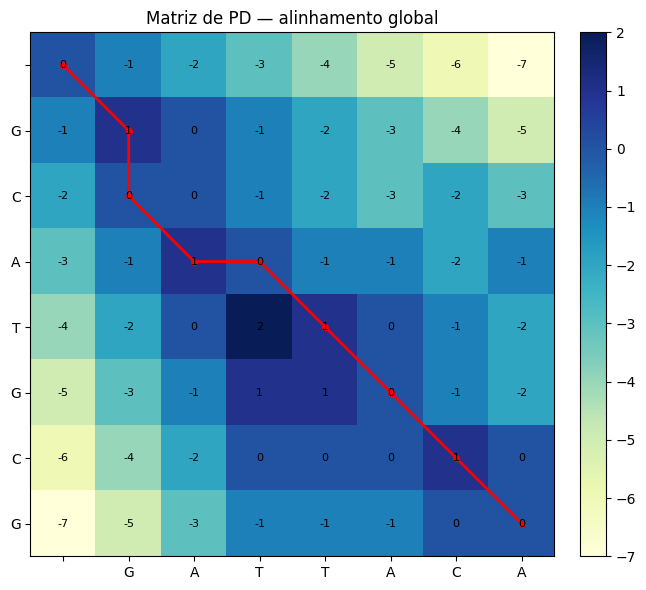

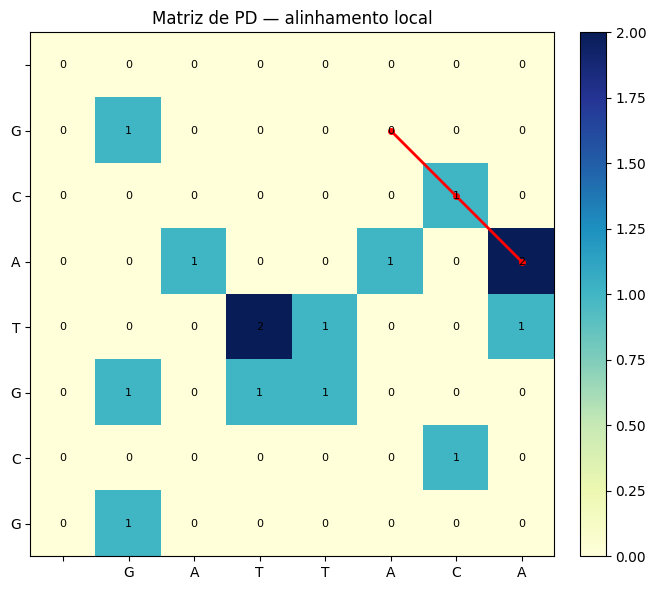

In [5]:
def dp_matrix(seq1, seq2, match=1, mismatch=-1, gap=-1, mode="global"):
    """Implementação didática simples de Needleman-Wunsch (global) e
    Smith-Waterman (local). Retorna a matriz de scores e a matriz de traceback."""
    n, m = len(seq1), len(seq2)
    H = np.zeros((n + 1, m + 1))
    traceback = np.zeros((n + 1, m + 1), dtype=int)  # 0=fim, 1=diagonal, 2=cima, 3=esquerda

    if mode == "global":
        for i in range(1, n + 1):
            H[i, 0] = H[i - 1, 0] + gap
            traceback[i, 0] = 2
        for j in range(1, m + 1):
            H[0, j] = H[0, j - 1] + gap
            traceback[0, j] = 3

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            s = match if seq1[i - 1] == seq2[j - 1] else mismatch
            diag = H[i - 1, j - 1] + s
            up = H[i - 1, j] + gap
            left = H[i, j - 1] + gap
            if mode == "local":
                best = max(0, diag, up, left)
            else:
                best = max(diag, up, left)
            H[i, j] = best
            if mode == "local" and best == 0:
                traceback[i, j] = 0
            elif best == diag:
                traceback[i, j] = 1
            elif best == up:
                traceback[i, j] = 2
            else:
                traceback[i, j] = 3
    return H, traceback


def traceback_path(H, traceback, mode="global"):
    n, m = H.shape[0] - 1, H.shape[1] - 1
    if mode == "local":
        i, j = np.unravel_index(np.argmax(H), H.shape)
    else:
        i, j = n, m
    path = [(i, j)]
    while True:
        step = traceback[i, j]
        if step == 0:
            break
        elif step == 1:
            i, j = i - 1, j - 1
        elif step == 2:
            i, j = i - 1, j
        else:
            i, j = i, j - 1
        path.append((i, j))
        if i == 0 and j == 0:
            break
    return path


def plot_dp_matrix(seq1, seq2, mode="global"):
    H, tb = dp_matrix(seq1, seq2, mode=mode)
    path = traceback_path(H, tb, mode=mode)

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(H, cmap="YlGnBu")
    ax.set_xticks(range(len(seq2) + 1))
    ax.set_yticks(range(len(seq1) + 1))
    ax.set_xticklabels([""] + list(seq2))
    ax.set_yticklabels([""] + list(seq1))
    for i in range(H.shape[0]):
        for j in range(H.shape[1]):
            ax.text(j, i, int(H[i, j]), ha="center", va="center", fontsize=8)
    path_rows = [p[0] for p in path]
    path_cols = [p[1] for p in path]
    ax.plot(path_cols, path_rows, color="red", linewidth=2, marker="o", markersize=4)
    ax.set_title(f"Matriz de PD — alinhamento {mode}")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


seq1 = "GCATGCG"
seq2 = "GATTACA"
plot_dp_matrix(seq1, seq2, mode="global")
plot_dp_matrix(seq1, seq2, mode="local")

No alinhamento **global**, o caminho em vermelho (traceback) sempre vai do canto inferior direito até o canto superior esquerdo da matriz — por isso ele é forçado a cobrir as duas sequências inteiras. No alinhamento **local**, o caminho começa na célula de maior score (não necessariamente no canto) e para assim que encontra uma célula com score 0 — por isso ele só cobre a sub-região mais bem alinhada.

Essa implementação é só para fins didáticos (não é otimizada e não lida com múltiplos empates como o Biopython faz) — para uso real, sempre prefira o `PairwiseAligner` do Biopython.

## Síntese

Responda com suas próprias palavras:
1. Por que o alinhamento global pode ter múltiplos resultados com o mesmo score máximo? Esse número tende a ser maior ou menor no alinhamento local, e por quê?
2. Em que cenário biológico você escolheria alinhamento local em vez de global?
3. Qual a diferença entre `gap_score` único e a penalidade afim (`open_gap_score` + `extend_gap_score`)? Por que essa distinção importa biologicamente?